In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/final_depression_dataset_1.csv


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [8]:
data = pd.read_csv('/kaggle/input/final_depression_dataset_1.csv')
df = pd.DataFrame(data)
df_cleaned = df.dropna(axis=1)

# 2. Encode categorical variables
le = LabelEncoder()
categorical_cols = df_cleaned.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# 3. Split features and target
X = df_cleaned.drop("Depression", axis=1)
y = df_cleaned["Depression"]


/tmp/ipykernel_24/333852744.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
/tmp/ipykernel_24/333852744.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
/tmp/ipykernel_24/333852744.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model training with Gradient Boosting
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions and accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Extract feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Results
print("Model Accuracy:", accuracy)
print("\nTop Features by Importance:")
print(feature_importances.head(10))

Model Accuracy: 0.8878748370273793

Top Features by Importance:
Age                                      0.472232
Have you ever had suicidal thoughts ?    0.216378
Financial Stress                         0.070195
Working Professional or Student          0.062218
Work/Study Hours                         0.058519
Name                                     0.035798
City                                     0.031535
Degree                                   0.019724
Dietary Habits                           0.019189
Sleep Duration                           0.010741
dtype: float64


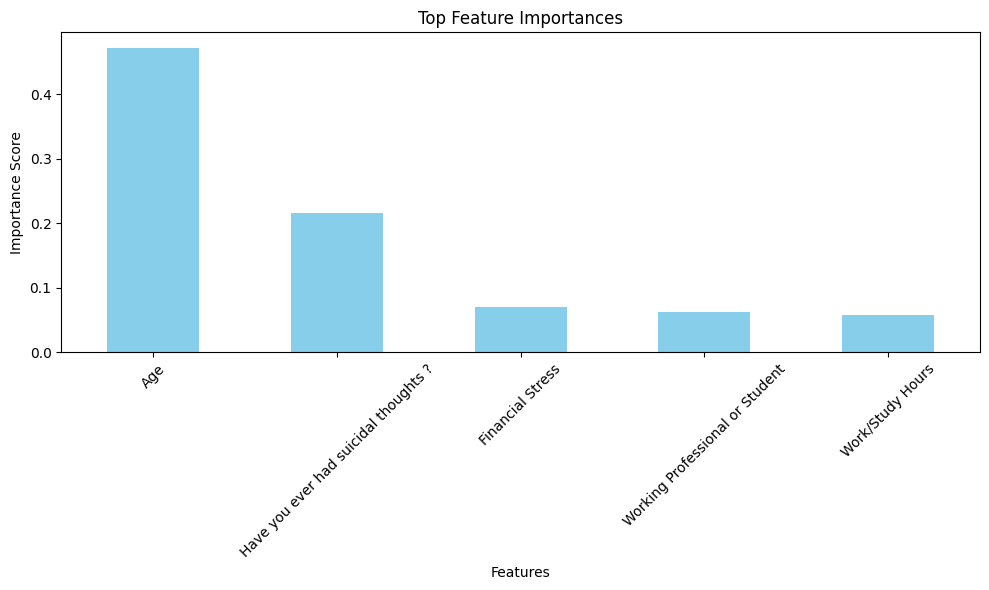

In [20]:
import matplotlib.pyplot as plt

# Visualization: Bar chart for top 10 feature importances
top_features = feature_importances.head(5)
plt.figure(figsize=(10, 6))
top_features.plot(kind="bar", color="skyblue")
plt.title("Top Feature Importances")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
top_5_features = feature_importances.head(5).index.tolist()
print(f"Top 5 features: {top_5_features}")

# 5. Retrain the model using only the top 5 features
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

model_top5 = GradientBoostingClassifier(random_state=42)
model_top5.fit(X_train_top5, y_train)

# 6. Make predictions and check accuracy
y_pred_top5 = model_top5.predict(X_test_top5)
accuracy_top5 = accuracy_score(y_test, y_pred_top5)
print(f"Accuracy with top 5 features: {accuracy_top5}")

Top 5 features: ['Age', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Working Professional or Student', 'Work/Study Hours']
Accuracy with top 5 features: 0.8904823989569752


In [19]:
# Ensure top_5_features is correctly set
top_5_features = ['Age', 'Have you ever had suicidal thoughts ?', 
                  'Financial Stress', 'Working Professional or Student', 'Work/Study Hours']

def predict_depression(input_data, model, top_features):
    """
    Predict depression status using the trained model and top features.
    
    Args:
    - input_data (dict): Dictionary containing feature values for prediction.
    - model (object): Trained model for prediction.
    - top_features (list): List of top features used by the model.
    
    Returns:
    - str: Prediction result ("Depression" or "No Depression").
    """
    # Convert the input data dictionary into a DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Ensure the input contains all required features and matches the model's format
    missing_features = set(top_features) - set(input_data.keys())
    if missing_features:
        raise ValueError(f"Missing required features for prediction: {missing_features}")
    
    input_df = input_df[top_features]  # Keep only the top features
    
    # Predict using the trained model
    prediction = model.predict(input_df)
    
    # Return result
    return "Depression" if prediction[0] == 1 else "No Depression"

# Example input
input_data = {
    "Age": 25, 
    "Have you ever had suicidal thoughts ?": 0,  # 0 for No, 1 for Yes
    "Financial Stress": 12, 
    "Working Professional or Student": 1,  # 0 for Student, 1 for Working Professional
    "Work/Study Hours": 6
}

# Predict using the trained model and updated top 5 features
try:
    prediction = predict_depression(input_data, model_top5, top_5_features)
    print(f"Prediction: {prediction}")
except ValueError as e:
    print(f"Error: {e}")


Prediction: No Depression
